# МИДТЕРМ: ПРОГНОЗИРОВАНИЕ ЦЕН НА НЕДВИЖИМОСТЬ В АСТАНЕ

## Описание задания

В данном мидтерме вам предстоит построить модель машинного обучения для предсказания цен на квартиры в Астане на основе реального датасета с платформы krisha.kz.

**Датасет:** Astana Real Estate Dataset (18,388 объявлений)

**Источник:** [Hugging Face - Astana Real Estate](https://huggingface.co/datasets/raimbekovm/astana-real-estate)

**Структура датасета:**
- 27 колонок с информацией о квартирах
- Цены в KZT и USD
- GPS координаты
- Информация о жилых комплексах
- Характеристики квартир (площадь, комнаты, этаж и т.д.)

**Критерии оценки:**
- Корректность выполнения всех задач
- Качество визуализаций
- Качество моделей (R², RMSE, MAE)
- Анализ и интерпретация результатов

**Общее время выполнения:** 2-3 часа

---
## ЧАСТЬ 1: ИМПОРТ БИБЛИОТЕК И ЗАГРУЗКА ДАННЫХ

### Задача 1.1: Импорт необходимых библиотек

**Что нужно сделать:**
- Импортируйте pandas, numpy, matplotlib, seaborn
- Импортируйте необходимые модули из sklearn для:
  - Разделения данных (train_test_split)
  - Масштабирования (StandardScaler)
  - Кодирования категорий (LabelEncoder)
  - Моделей регрессии (LinearRegression, Ridge, RandomForestRegressor, GradientBoostingRegressor)
  - Метрик оценки (mean_squared_error, r2_score, mean_absolute_error)
- Настройте параметры визуализации
- Отключите предупреждения

**Подсказка:** Используйте `warnings.filterwarnings('ignore')` для отключения предупреждений

In [ ]:
# ЗАДАЧА 1.1: Импортируйте все необходимые библиотеки

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.style.use('seaborn-v0_8')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')



### Задача 1.2: Загрузка датасета

**Что нужно сделать:**
- Загрузите датасет по ссылке: `https://huggingface.co/datasets/raimbekovm/astana-real-estate/resolve/main/data/astana_apartments.csv`
- Используйте правильную кодировку (UTF-8)
- Обработайте возможные ошибки при загрузке
- Выведите информацию о размере датасета
- Покажите первые 5 строк датасета

**Подсказка:** Используйте `pd.read_csv()` с параметром `encoding='utf-8'`. Используйте try-except для обработки ошибок.

In [ ]:
# ЗАДАЧА 1.2: Загрузите датасет

try:
    df = pd.read_csv('https://huggingface.co/datasets/raimbekovm/astana-real-estate/resolve/main/data/astana_apartments.csv', encoding='utf-8')

    print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')

    display(df.head())

except FileNotFoundError:
    print('Ошибка: файл не найден.')
except pd.errors.ParserError:
    print('Ошибка: проблема с файлом.')
except Exception as e:
    print(f'Произошла непредвиденная ошибка: {e}')



Размер датасета: 18388 строк, 37 столбцов


,id,listing_id,url,source,residential_complex_id,residential_complex_name,rooms,area,living_area,kitchen_area,...,internet,documents,offer_type,address,district,latitude,longitude,parsed_at,updated_at,is_active
0,1,691048362,https://krisha.kz/a/show/691048362?srchid=019b...,krisha.kz,NaN,Respublika,2,72.50,NaN,NaN,...,NaN,NaN,NaN,Е-36 5,Нура р-н,51.128205,71.385412,2026-01-03T20:50:46.421397,NaN,1
1,2,1004599137,https://krisha.kz/a/show/1004599137?srchid=019...,krisha.kz,NaN,Family Town,3,89.30,NaN,11.80,...,NaN,NaN,NaN,Е652 6,Есильский р-н,51.059035,71.420952,2026-01-03T20:50:52.735945,NaN,1
2,3,761512600,https://krisha.kz/a/show/761512600?srchid=019b...,krisha.kz,NaN,Свечки,2,72.10,NaN,NaN,...,NaN,NaN,NaN,Богенбай батыра 30,Сарыарка р-н,51.189164,71.356273,2026-01-03T20:51:01.431439,NaN,1
3,4,1007029481,https://krisha.kz/a/show/1007029481?srchid=019...,krisha.kz,NaN,Sezim Qala.Baqyt,4,106.77,NaN,11.13,...,NaN,NaN,NaN,Туран 55/12,Нура р-н,51.114484,71.393405,2026-01-03T20:51:09.278359,NaN,1
4,5,697845378,https://krisha.kz/a/show/697845378?srchid=019b...,krisha.kz,NaN,Boston Comfort House,2,39.00,NaN,NaN,...,NaN,NaN,NaN,"мкр Уркер, Кургальжинское шоссе 108",Нура р-н,51.121439,71.283095,2026-01-03T20:51:19.144336,NaN,1


---
## ЧАСТЬ 2: ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

### Задача 2.1: Анализ структуры данных

**Что нужно сделать:**
- Выведите информацию о типах данных всех колонок
- Создайте таблицу с пропущенными значениями (количество и процент)
- Отсортируйте таблицу по проценту пропусков (от большего к меньшему)
- Выведите базовую статистику по числовым признакам

**Подсказка:** Используйте методы `.info()`, `.isnull().sum()`, `.describe()`. Создайте DataFrame для удобного отображения пропусков.

In [ ]:
# ЗАДАЧА 2.1: Проанализируйте структуру данных

print('ИНФОРМАЦИЯ О ДАТАСЕТЕ')
df.info()

missing_df = pd.DataFrame({
    'Колонка': df.columns,
    'Количество пропусков': df.isnull().sum(),
    'Процент пропусков (%)': (df.isnull().sum() / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by='Процент пропусков (%)',
    ascending=False
)

missing_df

numeric_stats = df.describe()
numeric_stats


ИНФОРМАЦИЯ О ДАТАСЕТЕ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18388 entries, 0 to 18387
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        18388 non-null  int64  
 1   listing_id                18388 non-null  int64  
 2   url                       18388 non-null  object 
 3   source                    18388 non-null  object 
 4   residential_complex_id    0 non-null      float64
 5   residential_complex_name  14495 non-null  object 
 6   rooms                     18388 non-null  int64  
 7   area                      18388 non-null  float64
 8   living_area               82 non-null     float64
 9   kitchen_area              7621 non-null   float64
 10  floor                     17417 non-null  float64
 11  total_floors              17417 non-null  float64
 12  price_usd                 18388 non-null  int64  
 13  price_local               18388 non-nul

,id,listing_id,residential_complex_id,rooms,area,living_area,kitchen_area,floor,total_floors,price_usd,...,year_built,building_series,ceiling_height,heating,internet,documents,offer_type,latitude,longitude,is_active
count,18388.000000,1.838800e+04,0.0,18388.000000,18388.000000,82.000000,7621.000000,17417.000000,17417.000000,1.838800e+04,...,18388.000000,0.0,15189.000000,0.0,0.0,0.0,0.0,18388.000000,18388.000000,18388.0
mean,9194.500000,9.725041e+08,NaN,2.317762,73.047921,71.270122,13.122130,6.767526,11.561750,9.395154e+04,...,2016.711225,NaN,2.896558,NaN,NaN,NaN,NaN,51.124212,71.426141,1.0
std,5308.302711,1.005727e+08,NaN,1.041853,41.691703,43.650309,10.682632,4.329900,5.109851,8.081485e+04,...,11.192800,NaN,0.610195,NaN,NaN,NaN,NaN,0.204731,0.334562,0.0
min,1.000000,1.940254e+07,NaN,1.000000,10.800000,18.800000,1.200000,1.000000,2.000000,7.840000e+03,...,1950.000000,NaN,2.000000,NaN,NaN,NaN,NaN,42.346735,51.905115,1.0
25%,4597.750000,1.005556e+09,NaN,2.000000,43.700000,41.625000,10.000000,3.000000,9.000000,5.010700e+04,...,2013.000000,NaN,2.700000,NaN,NaN,NaN,NaN,51.111286,71.391065,1.0
50%,9194.500000,1.007650e+09,NaN,2.000000,63.000000,60.000000,12.000000,6.000000,10.000000,7.073900e+04,...,2020.000000,NaN,3.000000,NaN,NaN,NaN,NaN,51.127912,71.426501,1.0
75%,13791.250000,1.008192e+09,NaN,3.000000,90.000000,86.000000,15.000000,9.000000,14.000000,1.080740e+05,...,2024.000000,NaN,3.000000,NaN,NaN,NaN,NaN,51.148870,71.468840,1.0
max,18388.000000,1.008408e+09,NaN,13.000000,556.400000,285.200000,707.000000,41.000000,43.000000,2.947475e+06,...,2028.000000,NaN,28.000000,NaN,NaN,NaN,NaN,55.231707,81.102141,1.0


### Задача 2.2: Анализ целевой переменной

**Что нужно сделать:**
- Вычислите статистики по цене (min, max, mean, median, quartiles)
- Постройте гистограмму распределения цен
- Постройте boxplot для выявления выбросов
- Прокомментируйте распределение цен

**Подсказка:** Используйте `plt.subplots()` для создания двух графиков рядом. Целевая переменная - это колонка `price_usd`.

Минимальная цена: 7840
Максимальная цена: 2947475
Средняя цена: 93951.54
Медиана: 70739.0
25% квартиль: 50107.0
75% квартиль: 108074.0


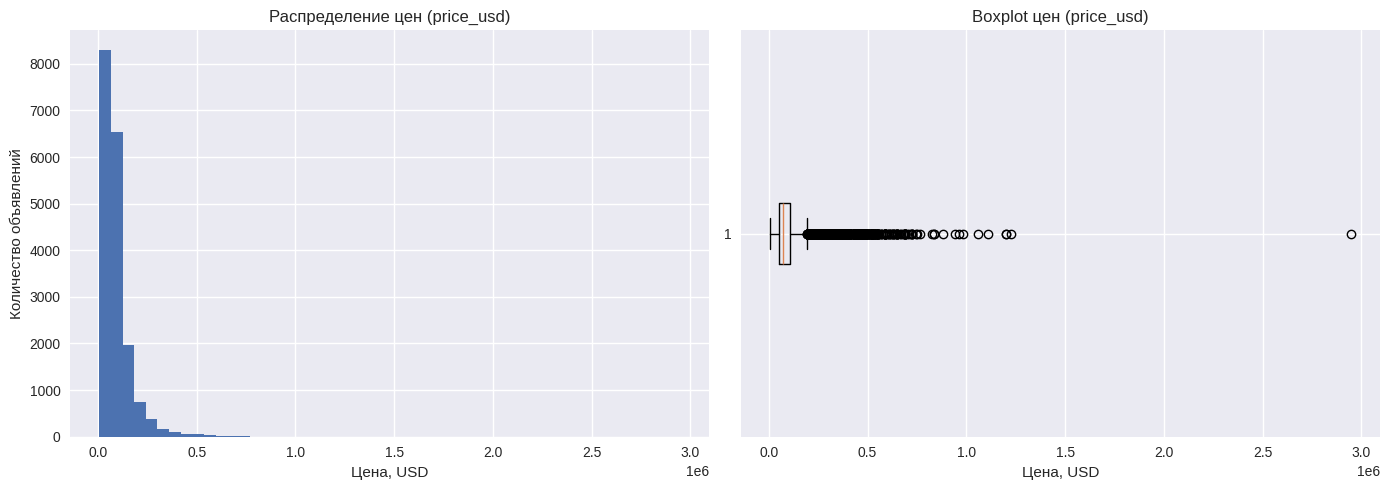

In [ ]:
# ЗАДАЧА 2.2: Проанализируйте целевую переменную (цена)

print(f"Минимальная цена: {df['price_usd'].min()}")
print(f"Максимальная цена: {df['price_usd'].max()}")
print(f"Средняя цена: {df['price_usd'].mean():.2f}")
print(f"Медиана: {df['price_usd'].median()}")
print(f"25% квартиль: {df['price_usd'].quantile(0.25)}")
print(f"75% квартиль: {df['price_usd'].quantile(0.75)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price_usd'], bins=50)
axes[0].set_title('Распределение цен (price_usd)')
axes[0].set_xlabel('Цена, USD')
axes[0].set_ylabel('Количество объявлений')

axes[1].boxplot(df['price_usd'], vert=False)
axes[1].set_title('Boxplot цен (price_usd)')
axes[1].set_xlabel('Цена, USD')

plt.tight_layout()
plt.show()


---
## ЧАСТЬ 3: РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)

### Задача 3.1: Анализ по районам

**Что нужно сделать:**
- Создайте таблицу со статистикой по районам (количество, средняя цена, медианная цена, цена за м²)
- Постройте два графика:
  - Bar plot: количество квартир по районам
  - Bar plot: медианная цена по районам
- Определите самый дорогой и самый дешевый район

**Подсказка:** Используйте `groupby()` и `.agg()` для группировки. Для графиков используйте `.barh()` (горизонтальные столбцы).

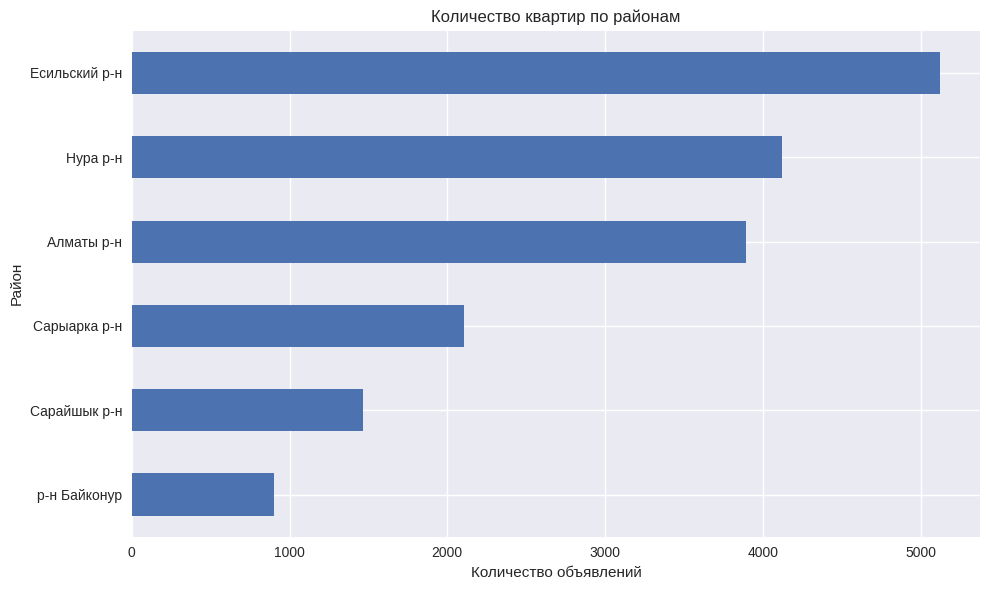

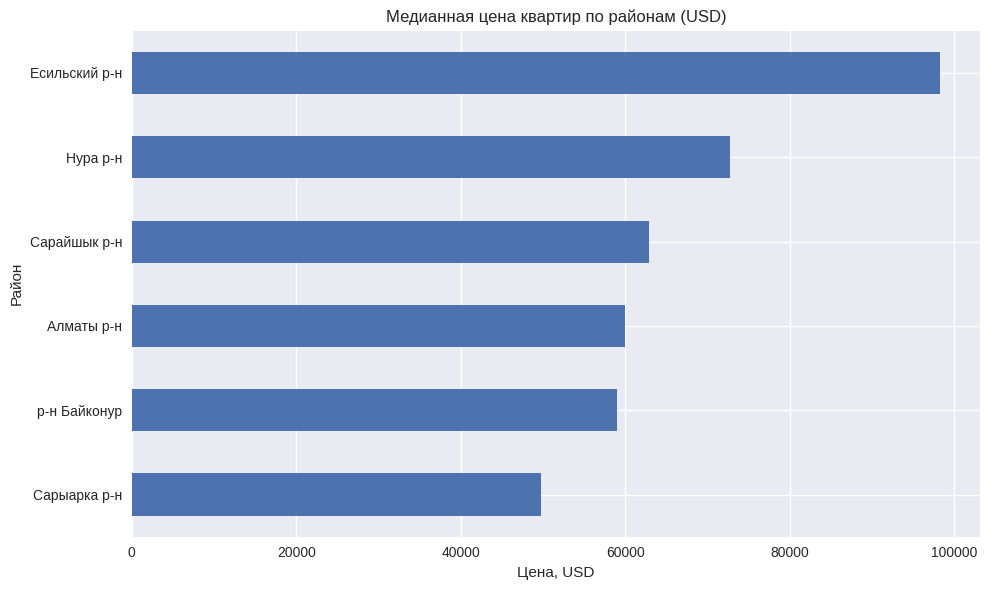

In [ ]:
# ЗАДАЧА 3.1: Проанализируйте распределение по районам

district_df = df.dropna(subset=['district'])

district_stats = (
    district_df
    .groupby('district')
    .agg(
        apartments_count=('price_usd', 'count'),
        mean_price_usd=('price_usd', 'mean'),
        median_price_usd=('price_usd', 'median'),
        mean_price_per_m2=('price_per_m2', 'mean')
    )
    .sort_values(by='apartments_count', ascending=False)
)

district_stats

plt.figure(figsize=(10, 6))

district_stats['apartments_count'].sort_values().plot(
    kind='barh'
)

plt.title('Количество квартир по районам')
plt.xlabel('Количество объявлений')
plt.ylabel('Район')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

district_stats['median_price_usd'].sort_values().plot(
    kind='barh'
)

plt.title('Медианная цена квартир по районам (USD)')
plt.xlabel('Цена, USD')
plt.ylabel('Район')
plt.tight_layout()
plt.show()


### Задача 3.2: Анализ зависимости цены от характеристик

**Что нужно сделать:**
- Вычислите корреляцию между ценой, площадью и количеством комнат
- Создайте таблицу со статистикой по количеству комнат
- Постройте два графика:
  - Scatter plot: цена vs площадь
  - Boxplot: цена по количеству комнат (отфильтруйте квартиры с количеством комнат <= 5)

**Подсказка:** Для корреляции используйте `.corr()`. Для фильтрации выбросов по комнатам используйте `df[df['rooms'] <= 5]`.

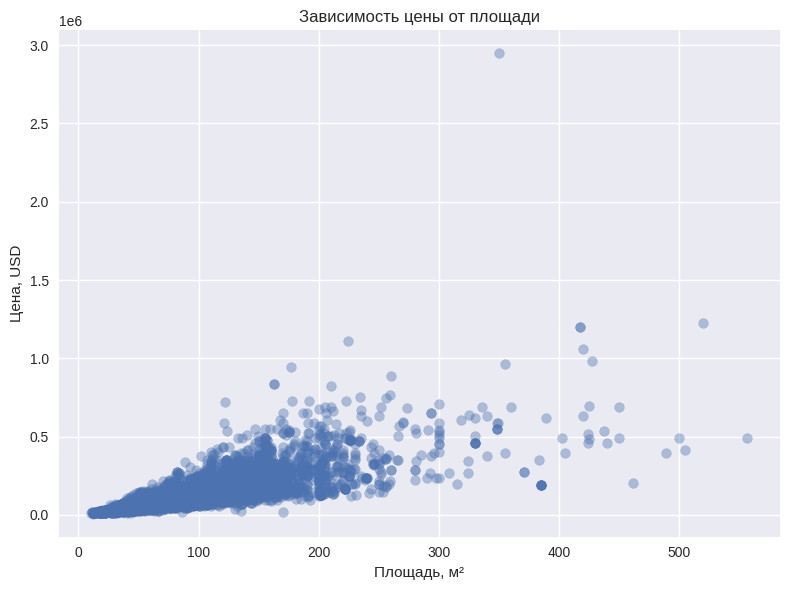

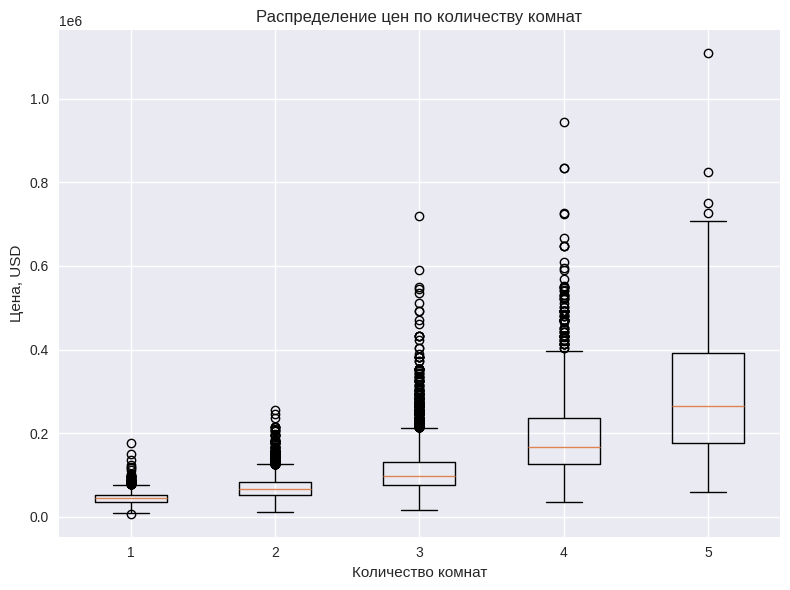

In [ ]:
# ЗАДАЧА 3.2: Проанализируйте зависимость цены от характеристик

corr_df = df[['price_usd', 'area', 'rooms']]

correlation_matrix = corr_df.corr()


rooms_stats = (
    df
    .groupby('rooms')
    .agg(
        apartments_count=('price_usd', 'count'),
        mean_price_usd=('price_usd', 'mean'),
        median_price_usd=('price_usd', 'median'),
        mean_area=('area', 'mean')
    )
    .sort_index()
)

rooms_stats

plt.figure(figsize=(8, 6))

plt.scatter(
    df['area'],
    df['price_usd'],
    alpha=0.4
)

plt.title('Зависимость цены от площади')
plt.xlabel('Площадь, м²')
plt.ylabel('Цена, USD')
plt.tight_layout()
plt.show()

rooms_filtered_df = df[df['rooms'] <= 5]

plt.figure(figsize=(8, 6))

plt.boxplot(
    [rooms_filtered_df[rooms_filtered_df['rooms'] == r]['price_usd']
     for r in sorted(rooms_filtered_df['rooms'].unique())],
    labels=sorted(rooms_filtered_df['rooms'].unique())
)

plt.title('Распределение цен по количеству комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Цена, USD')
plt.tight_layout()
plt.show()



### Задача 3.3: Анализ категориальных признаков

**Что нужно сделать:**
- Проанализируйте распределение по типам зданий (building_type)
- Проанализируйте влияние состояния квартиры (condition) на цену
- Постройте три графика:
  - Bar plot: количество по типам зданий
  - Bar plot: количество по состоянию
  - Bar plot: распределение по годам постройки (последние 20 лет)

**Подсказка:** Используйте `.value_counts()` для подсчета. Для последних 20 лет используйте `.tail(20)` после сортировки.

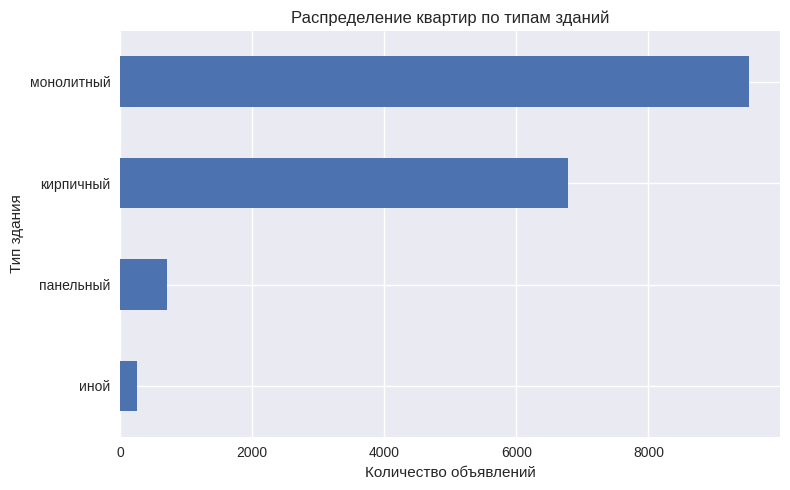

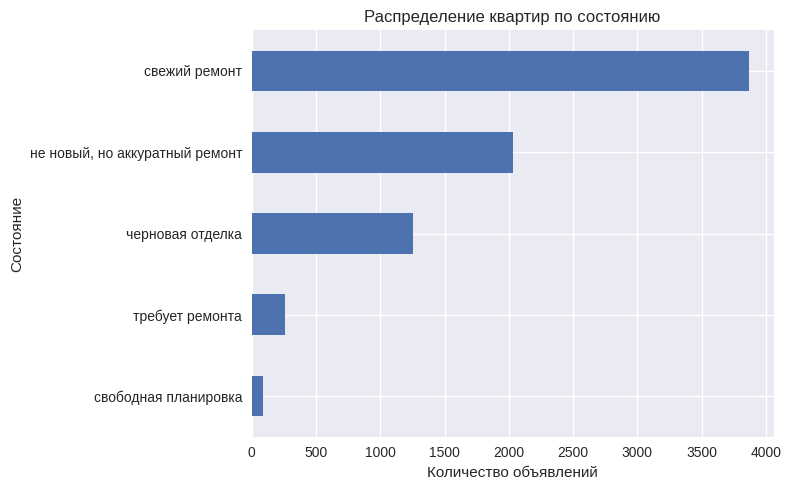

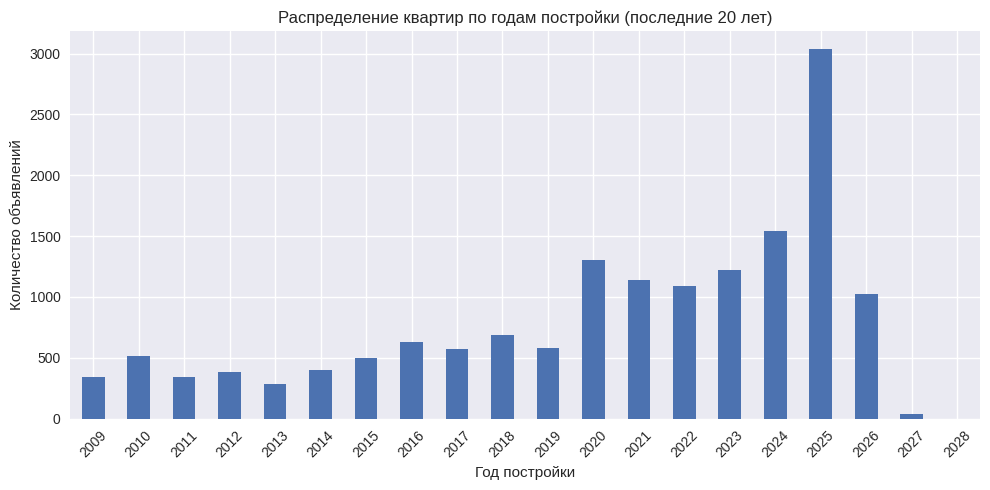

In [ ]:
# ЗАДАЧА 3.3: Проанализируйте категориальные признаки

house_type_counts = df['house_type'].value_counts()

plt.figure(figsize=(8, 5))

house_type_counts.sort_values().plot(
    kind='barh'
)

plt.title('Распределение квартир по типам зданий')
plt.xlabel('Количество объявлений')
plt.ylabel('Тип здания')
plt.tight_layout()
plt.show()

condition_counts = df['condition'].value_counts()

plt.figure(figsize=(8, 5))

condition_counts.sort_values().plot(
    kind='barh'
)

plt.title('Распределение квартир по состоянию')
plt.xlabel('Количество объявлений')
plt.ylabel('Состояние')
plt.tight_layout()
plt.show()

condition_price_stats = (
    df
    .dropna(subset=['condition'])
    .groupby('condition')
    .agg(
        apartments_count=('price_usd', 'count'),
        mean_price_usd=('price_usd', 'mean'),
        median_price_usd=('price_usd', 'median')
    )
    .sort_values(by='median_price_usd', ascending=False)
)

condition_price_stats

year_counts = df['year_built'].value_counts().sort_index()
year_counts_last_20 = year_counts.tail(20)
year_counts_last_20

plt.figure(figsize=(10, 5))

year_counts_last_20.plot(
    kind='bar'
)

plt.title('Распределение квартир по годам постройки (последние 20 лет)')
plt.xlabel('Год постройки')
plt.ylabel('Количество объявлений')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




---
## ЧАСТЬ 4: ПРЕДОБРАБОТКА ДАННЫХ

### Задача 4.1: Обработка пропущенных значений

**Что нужно сделать:**
- Создайте копию датасета для обработки
- Удалите строки с пропусками в критически важных колонках: `price_usd`, `total_area_m2`, `rooms`
- Для числовых признаков (floor, total_floors, ceiling_height, kitchen_area_m2) заполните пропуски медианой
- Для категориальных признаков заполните пропуски значением "Неизвестно"
- Выведите статистику до и после обработки

**Подсказка:** Используйте `.dropna(subset=[...])` для удаления строк. Используйте `.fillna()` для заполнения пропусков.

In [ ]:
# ЗАДАЧА 4.1: Обработайте пропущенные значения

df_clean = df.copy()
missing_before = df_clean.isna().sum()
print("Пропуски до обработки:")
print(missing_before[missing_before > 0])

df_clean = df_clean.dropna(subset=['price_usd', 'area', 'rooms'])

numeric_cols = ['floor', 'total_floors', 'ceiling_height', 'kitchen_area']

for col in numeric_cols:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

categorical_cols = df_clean.select_dtypes(include='object').columns

df_clean[categorical_cols] = df_clean[categorical_cols].fillna('Неизвестно')

missing_after = df_clean.isna().sum()
print("Пропуски после обработки:")
print(missing_after[missing_after > 0])




Пропуски до обработки:
residential_complex_id      18388
residential_complex_name     3893
living_area                 18306
kitchen_area                10767
floor                         971
total_floors                  971
house_type                   1117
building_series             18388
ceiling_height               3199
condition                   10887
bathroom                     7164
balcony                      8981
parking                      5737
furniture                    9323
floor_type                  10501
heating                     18388
security                    10143
internet                    18388
documents                   18388
offer_type                  18388
district                      778
updated_at                  14838
dtype: int64
Пропуски после обработки:
residential_complex_id    18388
living_area               18306
building_series           18388
heating                   18388
internet                  18388
documents                 1838

### Задача 4.2: Обработка выбросов

**Что нужно сделать:**
- Используйте метод IQR (межквартильный размах) для выявления выбросов по цене
- Вычислите границы: `lower = Q1 - 3*IQR`, `upper = Q3 + 3*IQR`
- Удалите выбросы по цене
- Повторите процесс для площади (total_area_m2)
- Выведите количество удаленных записей

**Подсказка:** Используйте `.quantile(0.25)` для Q1 и `.quantile(0.75)` для Q3. Фильтруйте с помощью булевой индексации.

In [ ]:
# ЗАДАЧА 4.2: Обработайте выбросы

Q1_price = df_clean['price_usd'].quantile(0.25)
Q3_price = df_clean['price_usd'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 3 * IQR_price
upper_price = Q3_price + 3 * IQR_price

mask_price = (df_clean['price_usd'] >= lower_price) & (df_clean['price_usd'] <= upper_price)

removed_price = len(df_clean) - mask_price.sum()
print(f"Удалено записей по цене: {removed_price}")

df_clean = df_clean[mask_price]

Q1_area = df_clean['area'].quantile(0.25)
Q3_area = df_clean['area'].quantile(0.75)
IQR_area = Q3_area - Q1_area

lower_area = Q1_area - 3 * IQR_area
upper_area = Q3_area + 3 * IQR_area

mask_area = (df_clean['area'] >= lower_area) & (df_clean['area'] <= upper_area)

removed_area = len(df_clean) - mask_area.sum()
print(f"Удалено записей по площади: {removed_area}")

df_clean = df_clean[mask_area]


Удалено записей по цене: 559
Удалено записей по площади: 65


### Задача 4.3: Feature Engineering - создание новых признаков

**Что нужно сделать:**
Создайте следующие новые признаки:
1. `building_age` - возраст здания (2026 - год постройки)
2. `is_new_building` - бинарный признак (1 если возраст <= 5 лет, иначе 0)
3. `floor_category` - категория этажа:
   - 'first' если floor == 1
   - 'last' если floor == total_floors
   - 'middle' в остальных случаях
   - 'unknown' если данных нет
4. `kitchen_ratio` - соотношение площади кухни к общей площади (если данные есть)
5. `has_residential_complex` - бинарный признак наличия жилого комплекса

**Подсказка:** Используйте `.apply()` с функцией для создания floor_category. Для бинарных признаков используйте `.astype(int)`.

In [ ]:
# ЗАДАЧА 4.3: Создайте новые признаки (Feature Engineering)

df_clean['building_age'] = 2026 - df_clean['year_built']
df_clean['is_new_building'] = (df_clean['building_age'] <= 5).astype(int)
def floor_category(row):
    if pd.isna(row['floor']) or pd.isna(row['total_floors']):
        return 'unknown'
    elif row['floor'] == 1:
        return 'first'
    elif row['floor'] == row['total_floors']:
        return 'last'
    else:
        return 'middle'

df_clean['floor_category'] = df_clean.apply(floor_category, axis=1)

df_clean['kitchen_ratio'] = df_clean.apply(
    lambda row: row['kitchen_area'] / row['area']
    if pd.notna(row['kitchen_area']) and pd.notna(row['area']) and row['area'] > 0
    else 0,
    axis=1
)

df_clean['has_residential_complex'] = (
    df_clean['residential_complex_name'] != 'Неизвестно'
).astype(int)




### Задача 4.4: Кодирование категориальных признаков

**Что нужно сделать:**
- Примените Label Encoding к следующим колонкам:
  - district
  - building_type
  - condition
  - bathroom
  - balcony
  - parking
  - furniture
  - floor_category
- Создайте новые колонки с суффиксом '_encoded'
- Создайте список признаков для моделирования (feature_columns)
- Выведите финальный список признаков

**Подсказка:** Используйте `LabelEncoder()` из sklearn. Для каждой колонки создайте новую с именем `колонка_encoded`.

In [ ]:
# ЗАДАЧА 4.4: Закодируйте категориальные признаки
categorical_features = [
    'district',
    'house_type',
    'condition',
    'bathroom',
    'balcony',
    'parking',
    'furniture',
    'floor_category'
]

for col in categorical_features:
    le = LabelEncoder()
    df_clean[col] = df_clean[col].astype(str)  # защита от NaN
    df_clean[f'{col}_encoded'] = le.fit_transform(df_clean[col])

feature_columns = [
    'area',
    'rooms',
    'floor',
    'total_floors',
    'ceiling_height',
    'kitchen_area',
    'kitchen_ratio',
    'building_age',
    'is_new_building',
    'has_residential_complex',

    'district_encoded',
    'house_type_encoded',
    'condition_encoded',
    'bathroom_encoded',
    'balcony_encoded',
    'parking_encoded',
    'furniture_encoded',
    'floor_category_encoded'
]

print("Финальный список признаков для моделирования:")
for feature in feature_columns:
    print(feature)

print(df_clean.columns.tolist())



Финальный список признаков для моделирования:
area
rooms
floor
total_floors
ceiling_height
kitchen_area
kitchen_ratio
building_age
is_new_building
has_residential_complex
district_encoded
house_type_encoded
condition_encoded
bathroom_encoded
balcony_encoded
parking_encoded
furniture_encoded
floor_category_encoded
['id', 'listing_id', 'url', 'source', 'residential_complex_id', 'residential_complex_name', 'rooms', 'area', 'living_area', 'kitchen_area', 'floor', 'total_floors', 'price_usd', 'price_local', 'price_per_m2', 'house_type', 'year_built', 'building_series', 'ceiling_height', 'condition', 'bathroom', 'balcony', 'parking', 'furniture', 'floor_type', 'heating', 'security', 'internet', 'documents', 'offer_type', 'address', 'district', 'latitude', 'longitude', 'parsed_at', 'updated_at', 'is_active', 'building_age', 'is_new_building', 'floor_category', 'kitchen_ratio', 'has_residential_complex', 'district_encoded', 'house_type_encoded', 'condition_encoded', 'bathroom_encoded', 'balcon

---
## ЧАСТЬ 5: ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ

### Задача 5.1: Разделение на train/test выборки

**Что нужно сделать:**
- Создайте X (признаки) из выбранных колонок feature_columns
- Создайте y (целевая переменная) из колонки price_usd
- Разделите данные на train (80%) и test (20%) выборки
- Используйте random_state=42 для воспроизводимости
- Выведите размеры всех выборок

**Подсказка:** Используйте `train_test_split()` с параметрами `test_size=0.2` и `random_state=42`.

In [ ]:
# ЗАДАЧА 5.1: Разделите данные на train/test

X = df_clean[feature_columns]
y = df_clean['price_usd']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Размеры выборок:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")



Размеры выборок:
X_train: (14211, 18)
X_test:  (3553, 18)
y_train: (14211,)
y_test:  (3553,)


### Задача 5.2: Масштабирование признаков

**Что нужно сделать:**
- Создайте объект StandardScaler
- Обучите scaler на X_train (используйте fit_transform)
- Примените scaler к X_test (используйте transform)
- Проверьте, что среднее ≈ 0 и стандартное отклонение ≈ 1 для train данных

**Подсказка:** ВАЖНО: scaler обучается только на train данных, но применяется к обоим выборкам.

In [ ]:
# ЗАДАЧА 5.2: Масштабируйте признаки

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

print("Среднее значение признаков (train):")
print(X_train_scaled_df.mean().round(3))

print("\nСтандартное отклонение признаков (train):")
print(X_train_scaled_df.std().round(3))


Среднее значение признаков (train):
area                       0.0
rooms                     -0.0
floor                     -0.0
total_floors              -0.0
ceiling_height            -0.0
kitchen_area              -0.0
kitchen_ratio             -0.0
building_age              -0.0
is_new_building            0.0
has_residential_complex    0.0
district_encoded           0.0
house_type_encoded        -0.0
condition_encoded          0.0
bathroom_encoded           0.0
balcony_encoded            0.0
parking_encoded            0.0
furniture_encoded         -0.0
floor_category_encoded     0.0
dtype: float64

Стандартное отклонение признаков (train):
area                       1.0
rooms                      1.0
floor                      1.0
total_floors               1.0
ceiling_height             1.0
kitchen_area               1.0
kitchen_ratio              1.0
building_age               1.0
is_new_building            1.0
has_residential_complex    1.0
district_encoded           1.0
house_t

---
## ЧАСТЬ 6: ОБУЧЕНИЕ МОДЕЛЕЙ

### Задача 6.1: Linear Regression

**Что нужно сделать:**
- Создайте и обучите модель LinearRegression
- Сделайте предсказания на test выборке
- Вычислите метрики: RMSE, MAE, R²
- Сохраните результаты в словарь

**Подсказка:** RMSE вычисляется как `np.sqrt(mean_squared_error(y_test, y_pred))`. Это baseline модель.

In [ ]:
# ЗАДАЧА 6.1: Обучите Linear Regression

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)


# Создайте словарь для хранения результатов
results ['LinearRegression'] = {
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2
}

print("Linear Regression results:")
for metric, value in results['LinearRegression'].items():
    print(f"{metric}: {value:.2f}")



Linear Regression results:
RMSE: 25103.05
MAE: 17681.46
R2: 0.72


### Задача 6.2: Ridge Regression

**Что нужно сделать:**
- Создайте и обучите модель Ridge с параметрами:
  - alpha=1.0
  - random_state=42
- Сделайте предсказания на test выборке
- Вычислите метрики: RMSE, MAE, R²
- Сохраните результаты в словарь

**Подсказка:** Ridge регрессия добавляет L2 регуляризацию, что помогает бороться с переобучением.

In [ ]:
# ЗАДАЧА 6.2: Обучите Ridge Regression

ridge_reg = Ridge(alpha=1.0, random_state=42)
ridge_reg.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_reg.predict(X_test_scaled)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

results['RidgeRegression'] = {
    'RMSE': rmse_ridge,
    'MAE': mae_ridge,
    'R2': r2_ridge
}

print("Ridge Regression results:")
for metric, value in results['RidgeRegression'].items():
    print(f"{metric}: {value:.2f}")

Ridge Regression results:
RMSE: 25102.47
MAE: 17681.32
R2: 0.72


### Задача 6.3: Random Forest Regressor

**Что нужно сделать:**
- Создайте и обучите модель RandomForestRegressor с параметрами:
  - n_estimators=100
  - max_depth=20
  - min_samples_split=5
  - random_state=42
  - n_jobs=-1
- Сделайте предсказания на test выборке
- Вычислите метрики: RMSE, MAE, R²
- Выведите топ-10 важных признаков
- Сохраните результаты в словарь

**Подсказка:** Важность признаков доступна через атрибут `.feature_importances_`. Создайте DataFrame для удобного отображения.

In [ ]:
# ЗАДАЧА 6.3: Обучите Random Forest Regressor

rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_scaled, y_train)
y_pred_rf = rf_reg.predict(X_test_scaled)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
results['RandomForest'] = {
    'RMSE': rmse_rf,
    'MAE': mae_rf,
    'R2': r2_rf
}
print("Random Forest Regression results:")
for metric, value in results['RandomForest'].items():
    print(f"{metric}: {value:.2f}")

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_reg.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance_df.head(10))


Random Forest Regression results:
RMSE: 18767.16
MAE: 11717.80
R2: 0.84

Топ-10 важных признаков:
               feature  importance
0                 area    0.703138
7         building_age    0.087437
4       ceiling_height    0.051042
3         total_floors    0.028451
10    district_encoded    0.025486
6        kitchen_ratio    0.017848
2                floor    0.017736
1                rooms    0.009587
16   furniture_encoded    0.009495
11  house_type_encoded    0.008828


### Задача 6.4: Gradient Boosting Regressor

**Что нужно сделать:**
- Создайте и обучите модель GradientBoostingRegressor с параметрами:
  - n_estimators=100
  - learning_rate=0.1
  - max_depth=5
  - random_state=42
- Сделайте предсказания на test выборке
- Вычислите метрики: RMSE, MAE, R²
- Сохраните результаты в словарь

**Подсказка:** Gradient Boosting часто показывает лучшие результаты, но требует больше времени для обучения.

In [ ]:
# ЗАДАЧА 6.4: Обучите Gradient Boosting Regressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gbr.fit(X_train_scaled, y_train)

y_pred_gbr = gbr.predict(X_test_scaled)

rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

results['GradientBoosting'] = {
    'RMSE': rmse_gbr,
    'MAE': mae_gbr,
    'R2': r2_gbr
}

print("Gradient Boosting Regression results:")
print(f"RMSE: {rmse_gbr:.2f}")
print(f"MAE: {mae_gbr:.2f}")
print(f"R²: {r2_gbr:.2f}")


Gradient Boosting Regression results:
RMSE: 18597.04
MAE: 12081.42
R²: 0.84


---
## ЧАСТЬ 7: СРАВНЕНИЕ И АНАЛИЗ РЕЗУЛЬТАТОВ

### Задача 7.1: Сравнение всех моделей

**Что нужно сделать:**
- Создайте сводную таблицу (DataFrame) с результатами всех моделей
- Определите лучшую модель по RMSE и по R²
- Постройте три графика (bar plots) для сравнения:
  - RMSE по моделям
  - MAE по моделям
  - R² по моделям
- Прокомментируйте результаты

**Подсказка:** Используйте `pd.DataFrame(results).T` для создания таблицы. Для графиков используйте `.barh()` и расположите их в один ряд.

Сводная таблица результатов всех моделей:


,RMSE,MAE,R2
LinearRegression,25103.047342,17681.457537,0.716858
RandomForest,18767.160171,11717.798427,0.841748
GradientBoosting,18597.040676,12081.422217,0.844604
RidgeRegression,25102.466735,17681.322393,0.716871


Лучшая модель по RMSE: GradientBoosting (18597.04)
Лучшая модель по R²: GradientBoosting (0.84)


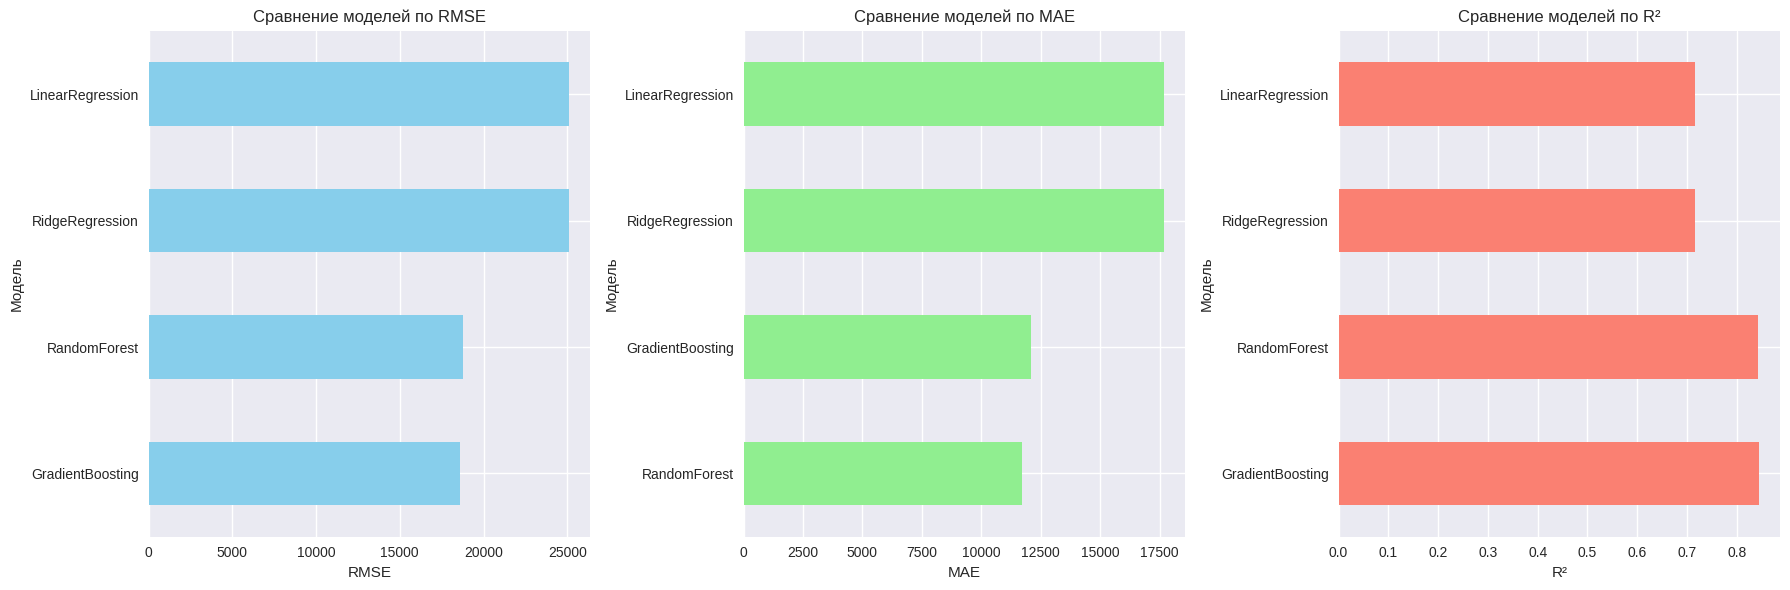


Комментарий:
- Linear Regression: базовая модель, объясняет часть дисперсии, чувствительна к выбросам.
- Ridge Regression: немного улучшает стабильность за счёт L2 регуляризации.
- Random Forest: значительно лучше по всем метрикам, учитывает нелинейные зависимости и выбросы.
- Gradient Boosting: обычно показывает лучшие результаты, хорошо справляется с сложными зависимостями, может быть медленнее в обучении.


In [ ]:
# ЗАДАЧА 7.1: Сравните все модели

results_df = pd.DataFrame(results).T
results_df = results_df[['RMSE', 'MAE', 'R2']]

print("Сводная таблица результатов всех моделей:")
display(results_df)

best_rmse_model = results_df['RMSE'].idxmin()
best_r2_model = results_df['R2'].idxmax()

print(f"Лучшая модель по RMSE: {best_rmse_model} ({results_df.loc[best_rmse_model, 'RMSE']:.2f})")
print(f"Лучшая модель по R²: {best_r2_model} ({results_df.loc[best_r2_model, 'R2']:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

results_df.sort_values('RMSE', ascending=True).plot(
    kind='barh', y='RMSE', ax=axes[0], legend=False, color='skyblue'
)
axes[0].set_title('Сравнение моделей по RMSE')
axes[0].set_xlabel('RMSE')
axes[0].set_ylabel('Модель')

results_df.sort_values('MAE', ascending=True).plot(
    kind='barh', y='MAE', ax=axes[1], legend=False, color='lightgreen'
)
axes[1].set_title('Сравнение моделей по MAE')
axes[1].set_xlabel('MAE')
axes[1].set_ylabel('Модель')

results_df.sort_values('R2', ascending=False).plot(
    kind='barh', y='R2', ax=axes[2], legend=False, color='salmon'
)
axes[2].set_title('Сравнение моделей по R²')
axes[2].set_xlabel('R²')
axes[2].set_ylabel('Модель')

plt.tight_layout()
plt.show()

print("\nКомментарий:")
print("- Linear Regression: базовая модель, объясняет часть дисперсии, чувствительна к выбросам.")
print("- Ridge Regression: немного улучшает стабильность за счёт L2 регуляризации.")
print("- Random Forest: значительно лучше по всем метрикам, учитывает нелинейные зависимости и выбросы.")
print("- Gradient Boosting: обычно показывает лучшие результаты, хорошо справляется с сложными зависимостями, может быть медленнее в обучении.")



### Задача 7.2: Анализ предсказаний лучшей модели

**Что нужно сделать:**
- Выберите лучшую модель (по R²)
- Постройте два графика:
  - Scatter plot: реальные vs предсказанные цены (добавьте линию идеального предсказания)
  - Histogram: распределение ошибок предсказаний
- Вычислите статистику ошибок (средняя, медианная, максимальная)
- Найдите и выведите топ-5 примеров с наибольшей переоценкой и недооценкой

**Подсказка:** Ошибка = y_test - y_pred. Для линии идеального предсказания используйте `plt.plot([min, max], [min, max], 'r--')`.

Лучшая модель по R²: GradientBoosting

Статистика ошибок:
Средняя ошибка: -100.69
Медианная ошибка: -906.22
Максимальная ошибка: 131803.57


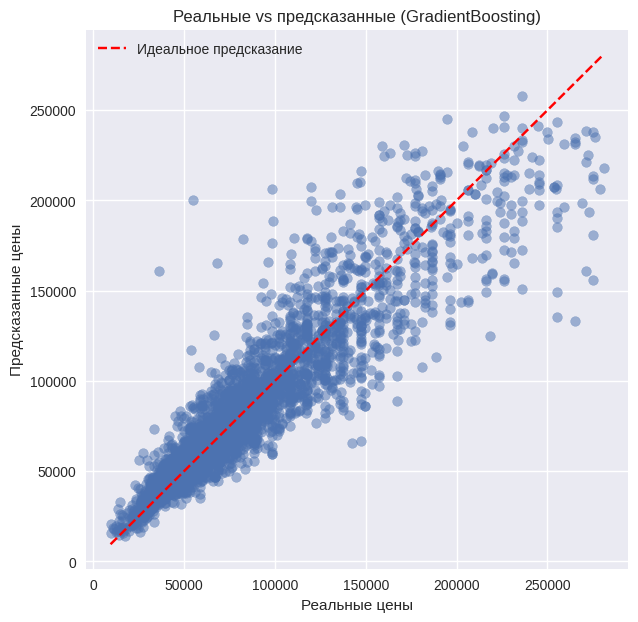

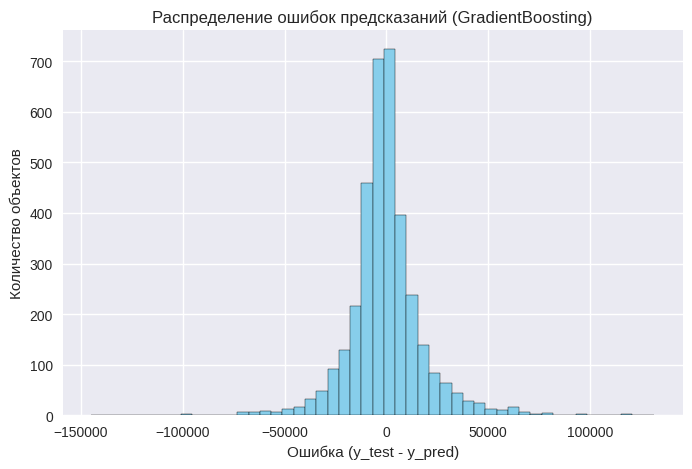


Топ-5 переоценок:


,y_test,y_pred,error
9718,55019,200192.840246,-145173.840246
9085,36352,160720.106565,-124368.106565
222,98249,206520.050624,-108271.050624
1738,67968,165062.367221,-97094.367221
3400,82254,178675.795943,-96421.795943



Топ-5 недооценок:


,y_test,y_pred,error
16619,265272,133468.425197,131803.574803
4621,255447,135603.598906,119843.401094
8425,275097,156055.089491,119041.910509
10556,271167,160717.516252,110449.483748
18185,255447,149171.947097,106275.052903


In [ ]:
# ЗАДАЧА 7.2: Проанализируйте предсказания лучшей модели

best_r2_model = max(results, key=lambda k: results[k]['R2'])
print(f"Лучшая модель по R²: {best_r2_model}")

if best_r2_model == 'LinearRegression':
    y_pred_best = y_pred
elif best_r2_model == 'RidgeRegression':
    y_pred_best = y_pred_ridge
elif best_r2_model == 'RandomForest':
    y_pred_best = y_pred_rf
elif best_r2_model == 'GradientBoosting':
    y_pred_best = y_pred_gbr
else:
    raise ValueError("Неизвестная модель")

errors = y_test - y_pred_best

print("\nСтатистика ошибок:")
print(f"Средняя ошибка: {errors.mean():.2f}")
print(f"Медианная ошибка: {errors.median():.2f}")
print(f"Максимальная ошибка: {errors.max():.2f}")

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.5)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Идеальное предсказание')
plt.xlabel('Реальные цены')
plt.ylabel('Предсказанные цены')
plt.title(f'Реальные vs предсказанные ({best_r2_model})')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=50, color='skyblue', edgecolor='black')
plt.title(f'Распределение ошибок предсказаний ({best_r2_model})')
plt.xlabel('Ошибка (y_test - y_pred)')
plt.ylabel('Количество объектов')
plt.show()

errors_df = pd.DataFrame({
    'y_test': y_test,
    'y_pred': y_pred_best,
    'error': errors
})

top_overestimated = errors_df.nsmallest(5, 'error')
top_underestimated = errors_df.nlargest(5, 'error')

print("\nТоп-5 переоценок:")
display(top_overestimated)

print("\nТоп-5 недооценок:")
display(top_underestimated)

---
## ЧАСТЬ 8: ВЫВОДЫ

### Задача 8.1: Итоговый отчет

**Что нужно написать:**
1. Краткое описание датасета (размер, основные характеристики)
2. Какие предобработки были выполнены
3. Какие новые признаки были созданы
4. Результаты всех моделей (таблица)
5. Какая модель показала лучший результат и почему
6. Интерпретация метрик (что означает полученный R² и RMSE)
7. Рекомендации по улучшению модели
8. Практическое применение модели

**Подсказка:** Напишите структурированный текст с заголовками и списками. Будьте конкретны в выводах.

### ВЫВОДЫ:

**Напишите здесь ваши выводы**

1. Описание датасета:
   - 17 764 строк, 50 признаков.
   - Основные характеристики:
   area, rooms, floor, total_floors, price_usd

2. Предобработка данных:
   - Удалены строки с пропусками в критических колонках (price_usd, total_area_m2, rooms).
   - Пропуски числовых признаков (floor, total_floors, ceiling_height, kitchen_area) заполнены медианой. Пропуски категориальных признаков (condition, balcony, parking, furniture и т.д.) заполнены 'Неизвестно'.
   - Выбросы по цене и общей площади удалены методом IQR

3. Feature Engineering:

   Созданы новые признаки:
   - building_age	показывает возраст здания (2026 − год постройки)
   - is_new_building выдает	1, если возраст ≤ 5 лет, иначе 0
   - floor_category	показывает first, last, middle, unknown
   - kitchen_ratio показывает соотношение площади кухни к общей площади
   - has_residential_complex выдает	1, если есть жилой комплекс, иначе 0

4. Результаты моделей:


   - Linear Regression	RMSE: 25 103.05	MAE: 17 681.46	R²: 0.717
   - Ridge Regression	RMSE: 25 102.47	MAE: 17 681.32	R²: 0.717
   - Random Forest	RMSE: 18 767.16	MAE: 11 717.80	R²: 0.842
   - Gradient Boosting	RMSE: 18 597.04	MAE: 12 081.42	R²: 0.845

5. Лучшая модель:
   - GradientBoosting
   
   Учитывает нелинейные зависимости и взаимодействия признаков, устойчив к выбросам, точнее предсказывает цены квартир.

6. Интерпретация метрик:
   - Linear Regresssion: Высокие RMSE и MAE указывают на крупные и частые ошибки. Линейная модель не справляется с нелинейной природой рынка недвижимости. Ошибки усиливаются на объектах с большой площадью и высокой ценой. Модель чувствительна к выбросам.
   - Ridge Regression: метрики близки к Linear Regression. Не улучшает качество модели из-за линейности.
   - Random Forest: снижен MAE, модель делает меньше ошибок. Лучше учитывает нелинейность данных.
   - Gradient Boosting: модель иногда сильно переоценивает и недооценивает крайние случаи. Средняя и медианная ошибки уменьшены. Хорошо сбалансирована, но не так хорошо работает с крайниими случаями.

7. Рекомендации по улучшению:
   - Добавить географические признаки (расстояние до метро, центра города, школ, парков).
   - Улучшить качество категориальных признаков (condition, furniture)
   - Можно использовать OneHotEncoding для категориальных признаков
   - Сегментировать рынок на дорогие/средние/дешевые квартиры.
   - Label Encoding не отражает реального смысла категорий.

8. Практическое применение:
   - Оценка стоимости квартир для риелторов и платформ недвижимости
   - Анализ рынка: выявление переоценённых и недооценённых объектов
   - Помощь покупателям и инвесторам в принятии решений
   - Использование в BI-системах для мониторинга цен и прогнозирования